# Krycklan GLUE results analysis

## Imports

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.5)

%matplotlib widget
%load_ext autoreload
%autoreload 2

In [40]:
data = pd.read_csv('../SpaFHy_RUNS/krycklan/results/glue_krycklan/100k_run_1/glue_results.csv', index_col=0)

# Calculate rank for each sample_id and metric

In [41]:
metrics = ['kge_tot','rmse_tot','mbe_tot', 'kge_sbsrf','rmse_sbsrf','mbe_sbsrf']
ascending_or_not = [False, True, True, False, True, True]
for metric in metrics:
    column_name = f'rank_{metric}'
    ascending = ascending_or_not[metrics.index(metric)]
    if 'mbe' in metric:
        data[column_name] = data[metric].abs().rank(method='min', ascending=ascending).astype(np.int32)
    else:
        data[column_name] = data[metric].rank(method='min', ascending=ascending).astype(np.int32)

In [42]:
# Adjust these weights to change the importance of each metric in the final ranking
w_kge = 0.5
w_rmse = 0.25
w_mbe = 0.25
N = len(data) # Total number of runs, used to flip rank to points (higher points = better rank)
data = data.assign(points_tot = (w_kge * (N - data['rank_kge_tot']) + w_rmse * (N - data['rank_rmse_tot']) + w_mbe * (N - data['rank_mbe_tot'])).astype(np.int32))
data = data.assign(points_sbsrf = (w_kge * (N - data['rank_kge_sbsrf']) + w_rmse * (N - data['rank_rmse_sbsrf']) + w_mbe * (N - data['rank_mbe_sbsrf'])).astype(np.int32))

data = data.assign(rank_tot = data['points_tot'].rank(method='min', ascending=True).astype(np.int32))
data = data.assign(rank_sbsrf = data['points_sbsrf'].rank(method='min', ascending=True).astype(np.int32))

# Glue analysis

Choose N best simulation based on metric

In [ ]:
metric = 'kge' # Possible metrics: kge, rmse, mbe, points
metric_cutoff_tot = 0.8#8500#data['points_tot'].quantile(0.95) #8500
metric_cutoff_sbsrf = 0.8#9000#data['points_sbsrf'].quantile(0.95) #9000

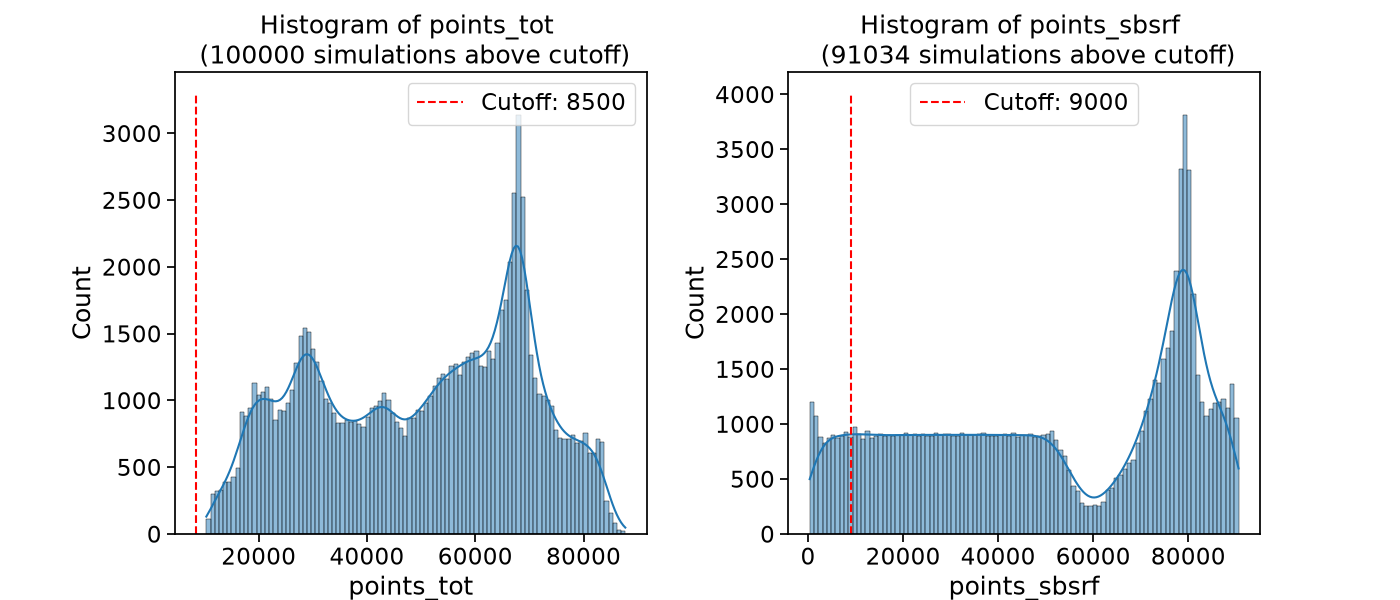

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
for idx, suffix in enumerate(['tot', 'sbsrf']):
    metric_col = f'{metric}_{suffix}'
    sns.histplot(data=data, x=metric_col, bins=100, kde=True, ax=ax[idx])
    if suffix == 'tot':
        metric_cutoff = metric_cutoff_tot
    else:
        metric_cutoff = metric_cutoff_sbsrf
    num_sims = (data[metric_col] >= metric_cutoff).sum()
    ax[idx].plot([metric_cutoff, metric_cutoff], [0, ax[idx].get_ylim()[1]], color='red', linestyle='--', label=f'Cutoff: {metric_cutoff}')
    ax[idx].set_title(f'Histogram of {metric_col} \n ({num_sims} simulations above cutoff)')
    ax[idx].legend()

In [26]:
suitable_simulations_tot = data[data[f'{metric}_tot'] >= metric_cutoff_tot]
suitable_simulations_sbsrf = data[data[f'{metric}_sbsrf'] >= metric_cutoff_sbsrf]

## Visualize range of suitable kmin, kmax and f 

In [27]:
F_BOUNDS = (6.0, 16.0)
K_MAX_BOUNDS = (1e-5, 0.1)
K_MIN_BOUNDS = (1e-9, 1e-6)

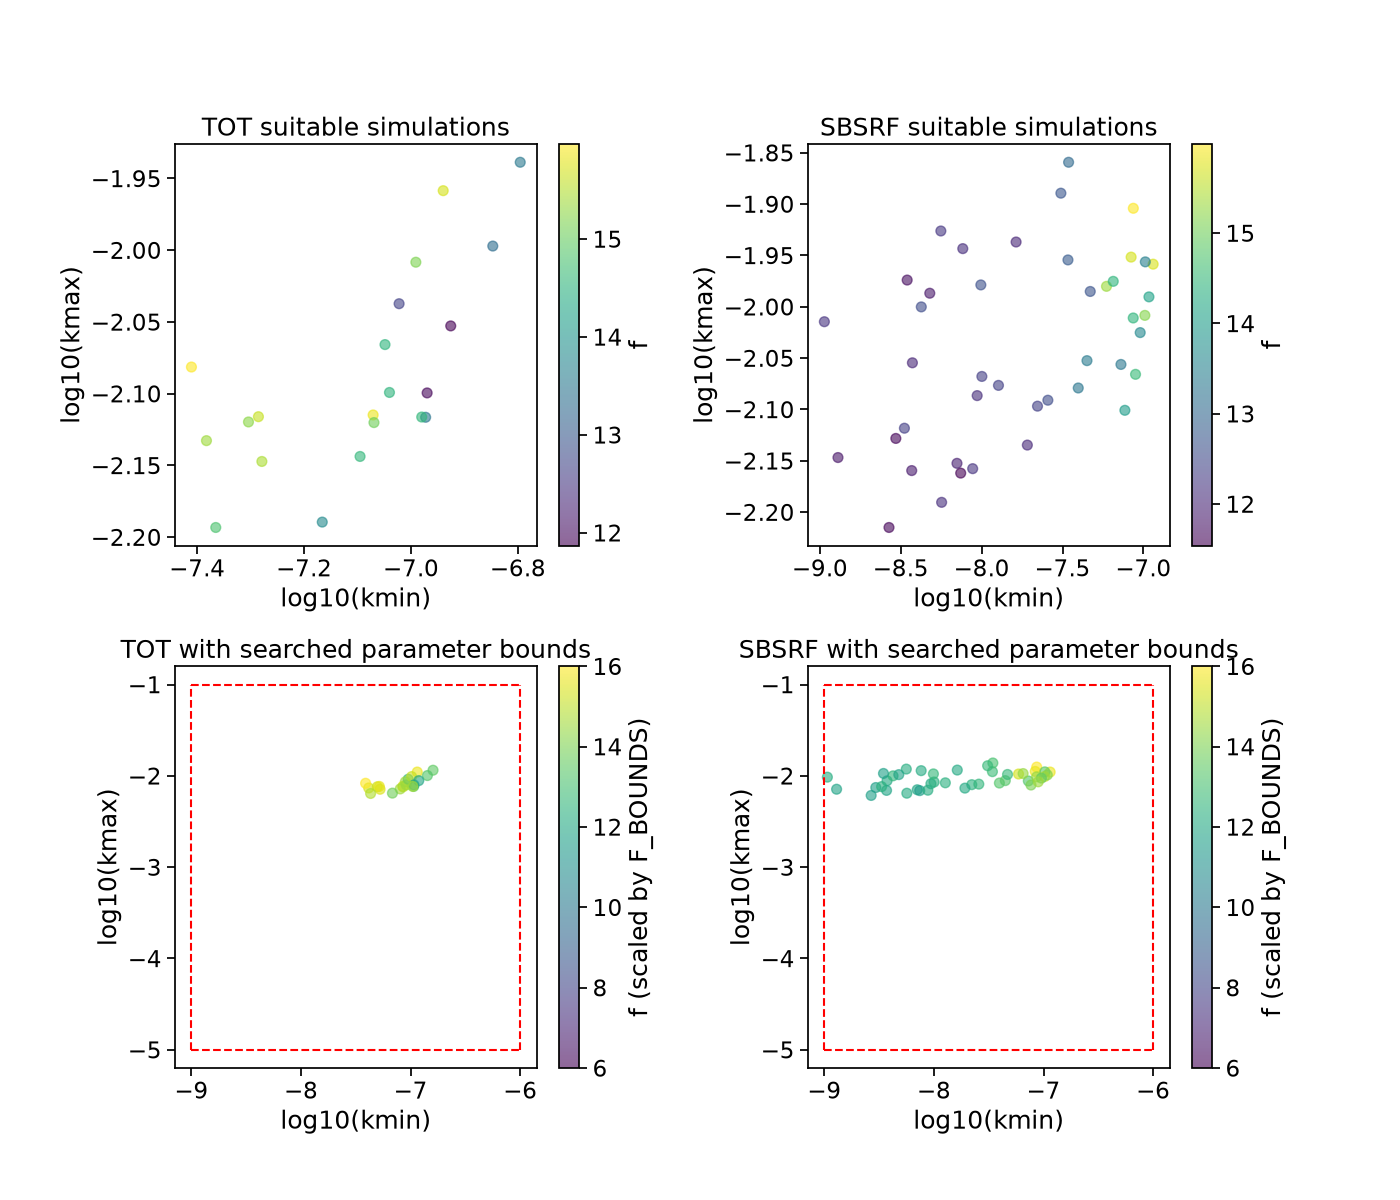

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=False, sharey=False)
fig.subplots_adjust(wspace=0.4, hspace=0.3)

x_tot = np.log10(suitable_simulations_tot['kmin_Medium'])
y_tot = np.log10(suitable_simulations_tot['kmax_Medium'])
f_tot = suitable_simulations_tot['f_Medium']

x_sbsrf = np.log10(suitable_simulations_sbsrf['kmin_Medium'])
y_sbsrf = np.log10(suitable_simulations_sbsrf['kmax_Medium'])
f_sbsrf = suitable_simulations_sbsrf['f_Medium']

sc00 = axes[0, 0].scatter(x_tot, y_tot, c=f_tot, cmap='viridis', s=50, alpha=0.6)
axes[0, 0].set_title('TOT suitable simulations')
axes[0, 0].set_xlabel('log10(kmin)')
axes[0, 0].set_ylabel('log10(kmax)')
fig.colorbar(sc00, ax=axes[0, 0], label='f')

sc01 = axes[0, 1].scatter(x_sbsrf, y_sbsrf, c=f_sbsrf, cmap='viridis', s=50, alpha=0.6)
axes[0, 1].set_title('SBSRF suitable simulations')
axes[0, 1].set_xlabel('log10(kmin)')
axes[0, 1].set_ylabel('log10(kmax)')
fig.colorbar(sc01, ax=axes[0, 1], label='f')

f_norm = plt.Normalize(vmin=F_BOUNDS[0], vmax=F_BOUNDS[1])
xmin, xmax = np.log10(K_MIN_BOUNDS[0]), np.log10(K_MIN_BOUNDS[1])
ymin, ymax = np.log10(K_MAX_BOUNDS[0]), np.log10(K_MAX_BOUNDS[1])

sc10 = axes[1, 0].scatter(x_tot, y_tot, c=f_tot, cmap='viridis', norm=f_norm, s=50, alpha=0.6)
axes[1, 0].vlines([xmin, xmax], ymin, ymax, colors='red', linestyles='--', linewidth=1.5)
axes[1, 0].hlines([ymin, ymax], xmin, xmax, colors='red', linestyles='--', linewidth=1.5)
axes[1, 0].set_title('TOT with searched parameter bounds')
axes[1, 0].set_xlabel('log10(kmin)')
axes[1, 0].set_ylabel('log10(kmax)')
fig.colorbar(sc10, ax=axes[1, 0], label='f (scaled by F_BOUNDS)')

sc11 = axes[1, 1].scatter(x_sbsrf, y_sbsrf, c=f_sbsrf, cmap='viridis', norm=f_norm, s=50, alpha=0.6)
axes[1, 1].vlines([xmin, xmax], ymin, ymax, colors='red', linestyles='--', linewidth=1.5)
axes[1, 1].hlines([ymin, ymax], xmin, xmax, colors='red', linestyles='--', linewidth=1.5)
axes[1, 1].set_title('SBSRF with searched parameter bounds')
axes[1, 1].set_xlabel('log10(kmin)')
axes[1, 1].set_ylabel('log10(kmax)')
fig.colorbar(sc11, ax=axes[1, 1], label='f (scaled by F_BOUNDS)')

## Visualize Ksat curve of suitable simulations

$$
K_{sat} = \left(K_{max} - K_{min}\right)e^{-fz} + K_{min}
$$

where z is depth between 0.3 - 10.0 m

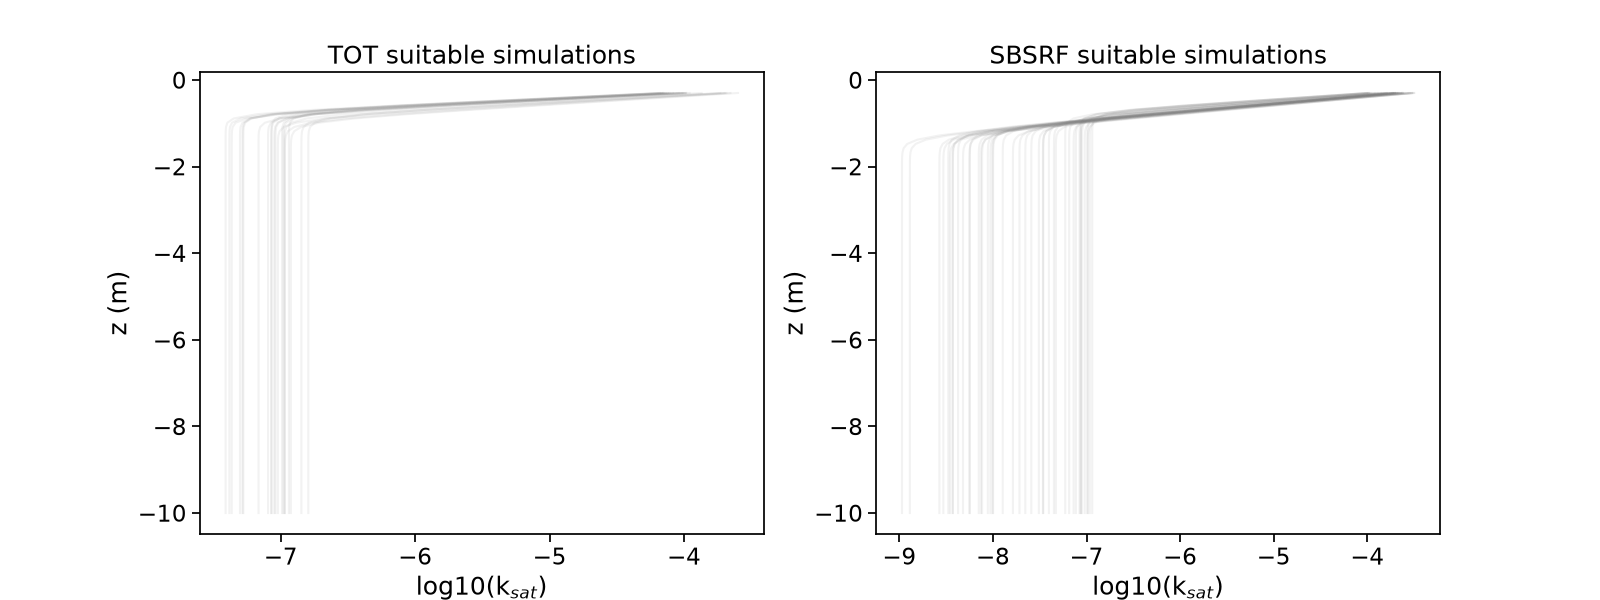

In [29]:
z = np.linspace(-0.3, -10, 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, suitable_simulations, title in zip(
    axes,
    [suitable_simulations_tot, suitable_simulations_sbsrf],
    ['TOT suitable simulations', 'SBSRF suitable simulations']
):
    for row in suitable_simulations.itertuples():
        kmin = row.kmin_Medium
        kmax = row.kmax_Medium
        f = row.f_Medium
        k_sat = (kmax - kmin) * np.exp(f * z) + kmin
        ax.plot(np.log10(k_sat), z, color='grey', alpha=0.1)
    ax.set_xlabel('log10(k$_{sat}$)')
    ax.set_ylabel('z (m)')
    ax.set_title(title)

# Show best simulation result time series

In [30]:
import os
from pathlib import Path
from run_best_krycklan_parameters import run_batch_simulations, run_single_simulation

project_folder = os.environ.get('PROJECT_FOLDER')
if project_folder is None:
    raise EnvironmentError('PROJECT_FOLDER is not set. Define it in .env or the environment.')

model_root = Path(project_folder) / 'krycklan'

print(f"Model root: {model_root}")
print(f"Output folder for netcdf will be: <glue_results_folder>/simulations")

Model root: /Users/opa/SpaFHy/krycklan/SpaFHy_RUNS/krycklan
Output folder for netcdf will be: <glue_results_folder>/simulations


## Load observations

In [31]:

from read_runoff import read_runoff

from pathlib import Path
runs_root = Path().resolve().parents[0] / 'SpaFHy_RUNS'
catchment_no = 2 # C2 catchment
runoff_folder = str(runs_root / 'krycklan' / 'obs' / 'DISCHARGE')  # runoff data folder
q_obs = read_runoff(catchment_no, runoff_folder)

In [32]:
from re import search as re_search

soil_type = 'Medium'
catchment = 'krycklan'
catchment_no = 2

print(f"Running simulations for {len(suitable_simulations_tot)} suitable total runoff models...")
results_tot = run_batch_simulations(
    suitable_simulations_tot,
    folder=str(model_root),
    q_obs=q_obs['Q'],
    output_folder=None,
    save_ncf=False,
    catchment=catchment,
    catchment_no=catchment_no,
    soil_type=soil_type,
    skip_existing=True,
    verbose=False,
)

print(f"Running simulations for {len(suitable_simulations_sbsrf)} suitable subsurface runoff models...")
results_sbsrf = run_batch_simulations(
    suitable_simulations_sbsrf,
    folder=str(model_root),
    q_obs=q_obs['Q'],
    output_folder=None,
    save_ncf=False,
    catchment=catchment,
    catchment_no=catchment_no,
    soil_type=soil_type,
    skip_existing=True,
    verbose=False,
)

print(f"✓ Total simulations completed: {len([r for r in results_tot.values() if r is not None])}")
print(f"✓ Subsurface simulations completed: {len([r for r in results_sbsrf.values() if r is not None])}")

Running simulations for 21 suitable total runoff models...
Running simulations for 43 suitable subsurface runoff models...
✓ Total simulations completed: 21
✓ Subsurface simulations completed: 43


In [33]:
def extract_best_and_ranges(results_dict, suitable_df, soil_type):
    """Extract best simulation and compute metric ranges."""
    q_dfs = {}
    params_list = []
    idx_list = []
    
    for idx, (q_df, params, _) in results_dict.items():
        if q_df is not None:
            q_dfs[idx] = q_df
            params_list.append(params)
            idx_list.append(idx)
    
    params_df_all = pd.DataFrame(params_list, index=idx_list)
    
    best_idx = params_df_all['rmse_tot'].idxmin()
    best_q_df = q_dfs[best_idx]
    best_params = params_df_all.loc[best_idx].to_dict()
    
    ranges = {
        'kge_tot': (params_df_all['kge_tot'].min(), params_df_all['kge_tot'].max()),
        'rmse_tot': (params_df_all['rmse_tot'].min(), params_df_all['rmse_tot'].max()),
        'mbe_tot': (params_df_all['mbe_tot'].min(), params_df_all['mbe_tot'].max()),
        'kge_sbsrf': (params_df_all['kge_sbsrf'].min(), params_df_all['kge_sbsrf'].max()),
        'rmse_sbsrf': (params_df_all['rmse_sbsrf'].min(), params_df_all['rmse_sbsrf'].max()),
        'mbe_sbsrf': (params_df_all['mbe_sbsrf'].min(), params_df_all['mbe_sbsrf'].max()),
    }
    
    return best_idx, best_q_df, best_params, ranges, q_dfs

best_idx_tot, best_q_df_tot, best_params_tot, ranges_tot, q_dfs_tot = extract_best_and_ranges(
    results_tot, suitable_simulations_tot, soil_type
)

best_idx_sbsrf, best_q_df_sbsrf, best_params_sbsrf, ranges_sbsrf, q_dfs_sbsrf = extract_best_and_ranges(
    results_sbsrf, suitable_simulations_sbsrf, soil_type
)

print(f"Best total runoff simulation: KGE={best_params_tot['kge_tot']:.2f}, RMSE={best_params_tot['rmse_tot']:.2f}")
print(f"Best subsurface runoff simulation: KGE={best_params_sbsrf['kge_sbsrf']:.2f}, RMSE={best_params_sbsrf['rmse_sbsrf']:.2f}")

Best total runoff simulation: KGE=0.75, RMSE=0.90
Best subsurface runoff simulation: KGE=0.72, RMSE=0.92


In [39]:
results_tot[305]

(               q_obs     q_sim  q_sim_srf  q_sim_sbsrf
 time                                                  
 2015-04-02  0.145210  0.223981   0.005350     0.218631
 2015-04-03  0.145210  0.223130   0.006294     0.216835
 2015-04-04  0.145210  0.219065   0.005453     0.213612
 2015-04-05  0.145210  0.215035   0.005311     0.209725
 2015-04-06  0.145210  0.223521   0.017699     0.205823
 ...              ...       ...        ...          ...
 2015-09-27  0.615630  0.675650   0.009913     0.665737
 2015-09-28  0.456807  0.602051   0.012090     0.589961
 2015-09-29  0.400840  0.548907   0.011134     0.537773
 2015-09-30  0.358487  0.513445   0.008372     0.505073
 2015-10-01  0.305546  0.494305   0.016168     0.478137
 
 [178 rows x 4 columns],
 {'kmax_Medium': 0.00767681110528,
  'kmin_Medium': 8.494425541278134e-08,
  'f_Medium': 15.845776077073593,
  'kge_tot': np.float64(0.7486614848095245),
  'rmse_tot': np.float64(0.9013713550006086),
  'mbe_tot': np.float64(0.0870033531834899),


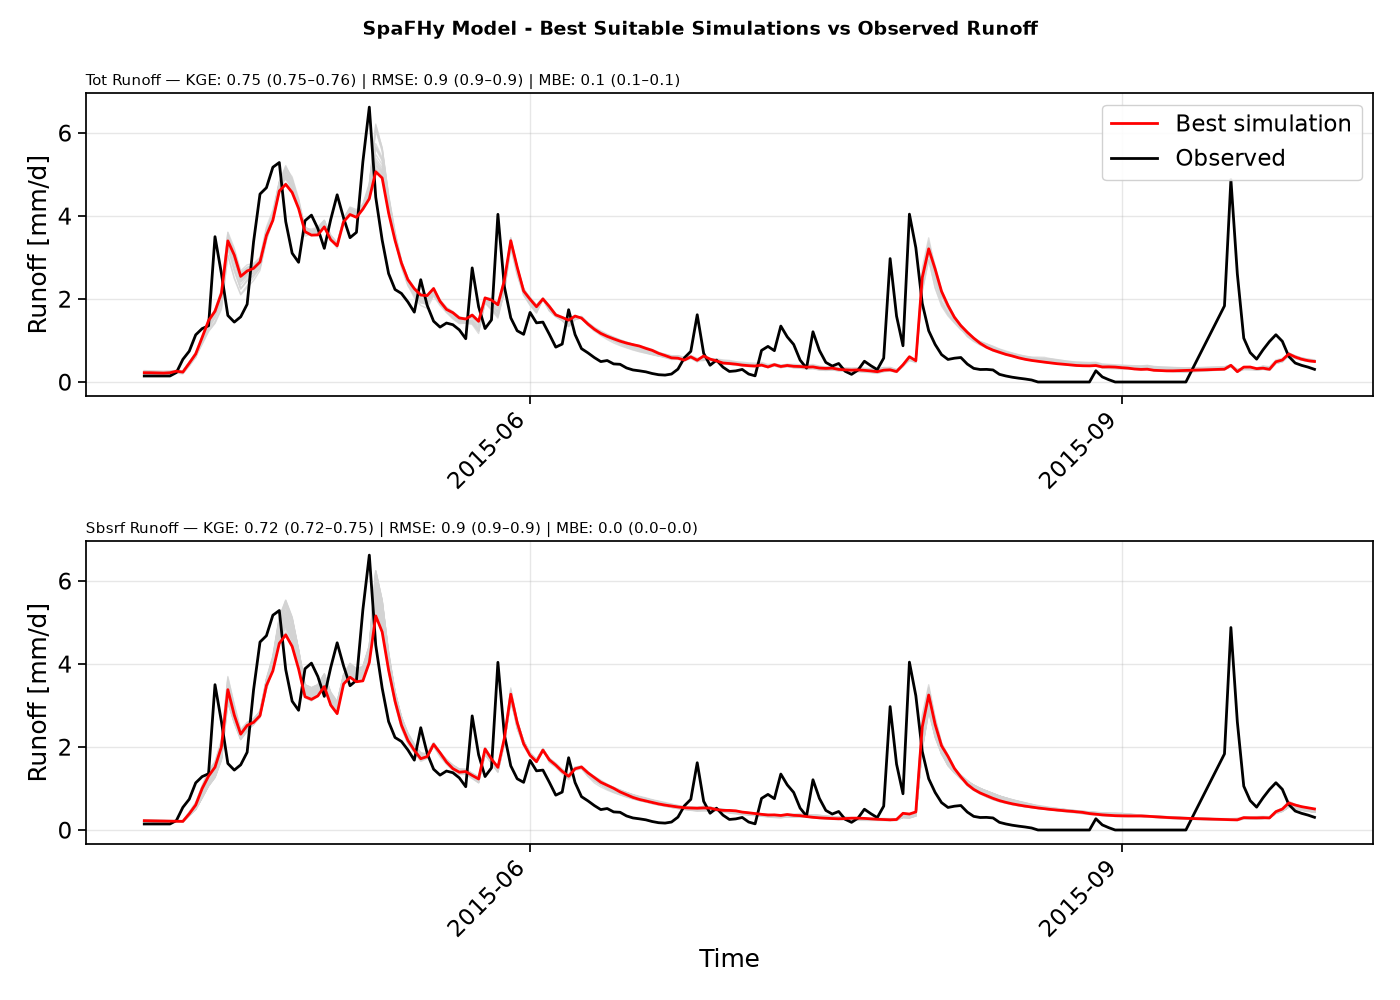


Visualization complete! All suitable simulations shown as light gray swarm.
Best simulation (red) and observed runoff (black) highlighted with thick lines.


In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('SpaFHy Model - Best Suitable Simulations vs Observed Runoff', fontsize=14, fontweight='bold')

runoff_types = [
    ('tot', 'q_sim', best_idx_tot, best_params_tot, ranges_tot, q_dfs_tot, best_q_df_tot, axes[0]),
    ('sbsrf', 'q_sim_sbsrf', best_idx_sbsrf, best_params_sbsrf, ranges_sbsrf, q_dfs_sbsrf, best_q_df_sbsrf, axes[1])
]

for runoff_type, q_col, best_idx, best_params, ranges, q_dfs, best_q_df, ax in runoff_types:
    
    for idx, q_df in q_dfs.items():
        if idx != best_idx:
            ax.plot(q_df.index, q_df[q_col], color='lightgray', linewidth=1, alpha=0.75, label='_nolegend_')
    
    ax.plot(best_q_df.index, best_q_df[q_col], color='red', linewidth=2, label='Best simulation', zorder=5)
    ax.plot(best_q_df.index, best_q_df['q_obs'], color='black', linewidth=2, label='Observed', zorder=4)
    
    kge_val = best_params[f'kge_{runoff_type}']
    kge_min, kge_max = ranges[f'kge_{runoff_type}']
    rmse_val = best_params[f'rmse_{runoff_type}']
    rmse_min, rmse_max = ranges[f'rmse_{runoff_type}']
    mbe_val = best_params[f'mbe_{runoff_type}']
    mbe_min, mbe_max = ranges[f'mbe_{runoff_type}']
    
    title = (f"{runoff_type.capitalize()} Runoff — "
             f"KGE: {kge_val:.2f} ({kge_min:.2f}–{kge_max:.2f}) | "
             f"RMSE: {rmse_val:.1f} ({rmse_min:.1f}–{rmse_max:.1f}) | "
             f"MBE: {mbe_val:.1f} ({mbe_min:.1f}–{mbe_max:.1f})")
    ax.set_title(title, fontsize=11, loc='left')
    
    ax.set_ylabel('Runoff [mm/d]')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    if ax == axes[0]:
        ax.legend(loc='upper right', framealpha=0.9)

axes[1].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("\nVisualization complete! All suitable simulations shown as light gray swarm.")
print("Best simulation (red) and observed runoff (black) highlighted with thick lines.")